<a href="https://www.kaggle.com/code/bassetkerouche/voting-classifier-hard-and-soft-for-loan-approval?scriptVersionId=289671048" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## 1 Import Libraries¶


In [77]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import pyplot as plt
from sklearn.model_selection import cross_val_score
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler


## 2. Import Data

In [134]:
n_samples_test=1000

train=pd.read_csv('/kaggle/input/playground-series-s4e10/train.csv')#[:n_samples_test]
test=pd.read_csv('/kaggle/input/playground-series-s4e10/test.csv')#[:n_samples_test]
submission=pd.read_csv("/kaggle/input/playground-series-s4e10/sample_submission.csv")#[:n_samples_test]
org_data=pd.read_csv("/kaggle/input/loan-approval-prediction/credit_risk_dataset.csv")#[:n_samples_test]

train.drop(columns=["id"],inplace=True)
test.drop(columns=["id"],inplace=True)

train_copy=train.copy()
test_copy=test.copy()

target_col='loan_status'

train.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...
58640,34,120000,MORTGAGE,5.0,EDUCATION,D,25000,15.95,0.21,Y,10,0
58641,28,28800,RENT,0.0,MEDICAL,C,10000,12.73,0.35,N,8,1
58642,23,44000,RENT,7.0,EDUCATION,D,6800,16.00,0.15,N,2,1
58643,22,30000,RENT,2.0,EDUCATION,A,5000,8.90,0.17,N,3,0


In [152]:
train=pd.concat([train,org_data],axis=0).drop_duplicates()
train.dropna(inplace=True)
train=train.reset_index(drop=True)

## 3. Data pre-processing

### 3.1 Checking for outliers


In [79]:
num_cols=train.select_dtypes(include=np.number).columns.tolist()
num_cols=[col for col in num_cols if col not in ["loan_status"]]
cat_cols=train.select_dtypes(exclude=np.number).columns.tolist()


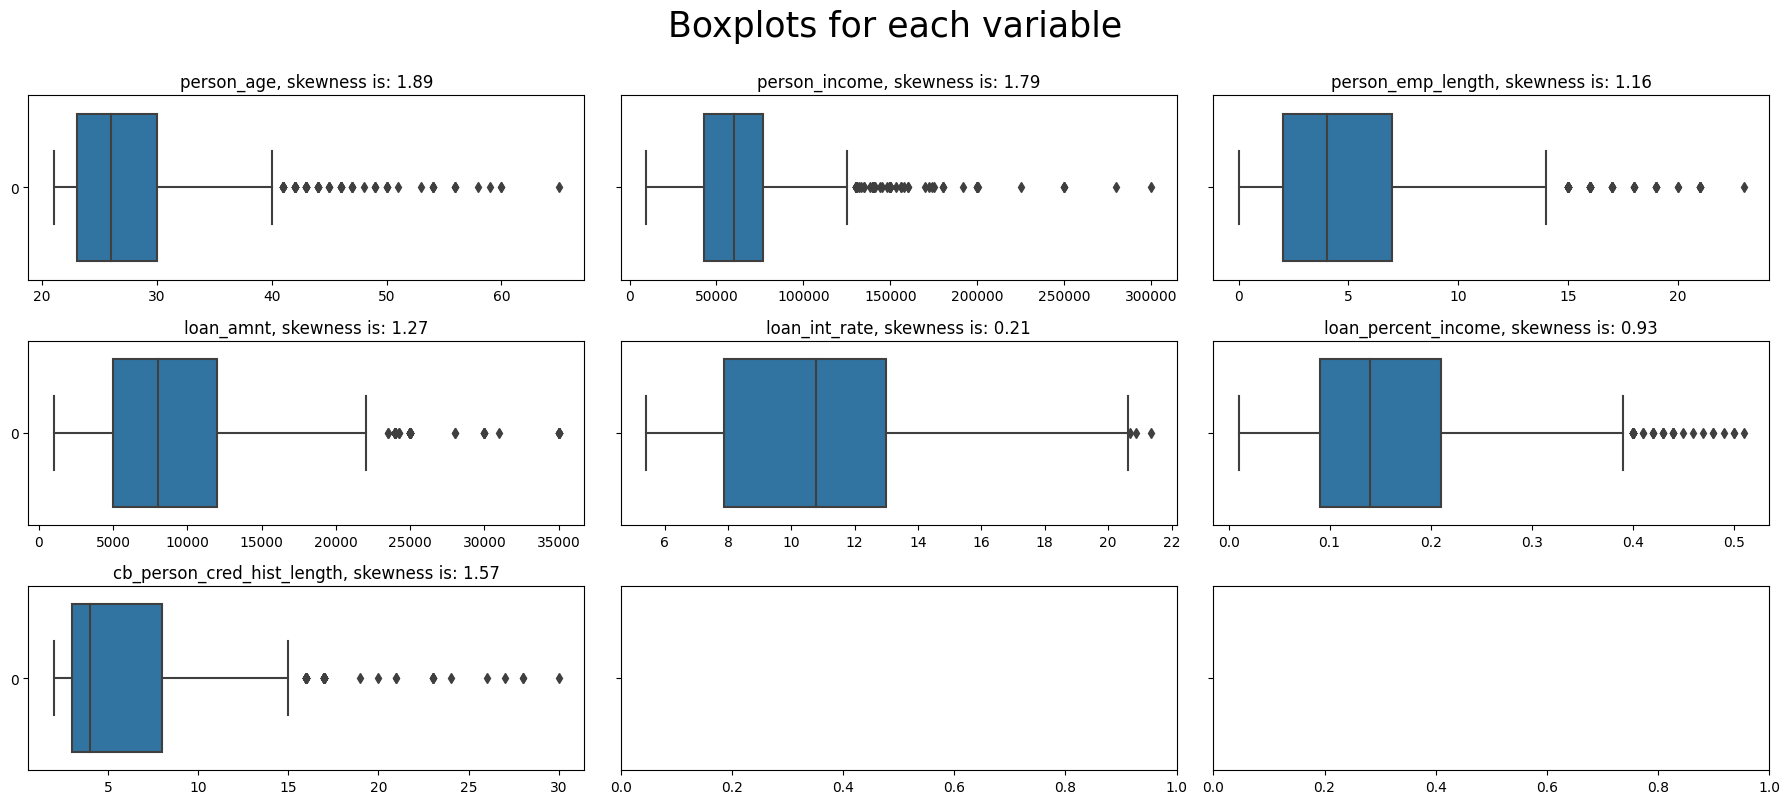

In [80]:
# checking boxplots
def boxplots_custom(dataset, columns_list, rows, cols, suptitle):
    fig, axs = plt.subplots(rows, cols, sharey=True, figsize=(18,8))
    fig.suptitle(suptitle,y=1, size=25)
    axs = axs.flatten()
    for i, data in enumerate(columns_list):
        sns.boxplot(data=dataset[data], orient='h', ax=axs[i])
        axs[i].set_title(data + ', skewness is: '+str(round(dataset[data].skew(axis = 0, skipna = True),2)))
        
boxplots_custom(dataset=train, columns_list=num_cols, rows=3, cols=3, suptitle='Boxplots for each variable')
plt.tight_layout()

### 3.2 Dropping outliers

In [81]:
def IQR_method (df,n,features):
    """
    Takes a dataframe and returns an index list corresponding to the observations 
    containing more than n outliers according to the Tukey IQR method.
    """
    outlier_list = []
    
    for column in features:
        # 1st quartile (25%)
        Q1 = np.percentile(df[column], 25)
        # 3rd quartile (75%)
        Q3 = np.percentile(df[column],75)
        # Interquartile range (IQR)
        IQR = Q3 - Q1
        # outlier step
        outlier_step = 1.5 * IQR
        # Determining a list of indices of outliers
        outlier_list_column = df[(df[column] < Q1 - outlier_step) | (df[column] > Q3 + outlier_step )].index
        # appending the list of outliers 
        outlier_list.extend(outlier_list_column)
    # selecting observations containing more than x outliers
    outlier_list = Counter(outlier_list)        
    multiple_outliers = list( k for k, v in outlier_list.items() if v > n )
    # Calculate the number of records below and above lower and above bound value respectively
    out1 = df[df[column] < Q1 - outlier_step]
    out2 = df[df[column] > Q3 + outlier_step]
    
    print('Total number of deleted outliers is:', out1.shape[0]+out2.shape[0])
    
    return multiple_outliers

In [82]:
# detecting outliers
Outliers_IQR = IQR_method(train,1,num_cols)

# dropping outliers
train = train.drop(Outliers_IQR, axis = 0).reset_index(drop=True)

Total number of deleted outliers is: 63


### 3.3 Data imbalance check¶


In [83]:
labels=["Refused","Accepted"]

status_a_r = train['loan_status'].value_counts().tolist()
values = [status_a_r[0], status_a_r[1]]

fig = px.pie(values=train['loan_status'].value_counts(), names=labels , width=700, height=400, color_discrete_sequence=["skyblue","black"]
             ,title="Loan Status Accepted or Refused")
fig.show()

There are many techniques which can be used to handle imbalanced data in machine learning ,I choice one of theme  like Combining oversampling and undersampling




**Note:**

* excessive oversampling leads to overfitting as same instances are repeated multiple times
* excessive undersampling leads to underfitting as their is loss of information

So, a balance needs to be found between oversampling and undersampling


In [84]:
def plot_distribution_plot(distribution: pd.Series, title: str):
    sns.barplot(x=distribution.index, y=distribution.values, palette="GnBu")
    plt.title(title)
    plt.show()

In [85]:
target = train['loan_status']
data=train.drop(['loan_status'],axis=1)


In [86]:
oversampler_df = RandomOverSampler(sampling_strategy=0.505)
oversampled_data, oversampled_target = oversampler_df.fit_resample(data, target)


In [87]:
oversampled_data.shape


(2563, 11)

In [88]:
oversampled_target.value_counts()


loan_status
0    1703
1     860
Name: count, dtype: int64

In [89]:
undersampler_df = RandomUnderSampler(sampling_strategy=1.0)
undersampled_data, undersampled_target = undersampler_df.fit_resample(oversampled_data, oversampled_target)

In [90]:
undersampled_data.shape


(1720, 11)

In [91]:
undersampled_target.value_counts()


loan_status
0    860
1    860
Name: count, dtype: int64

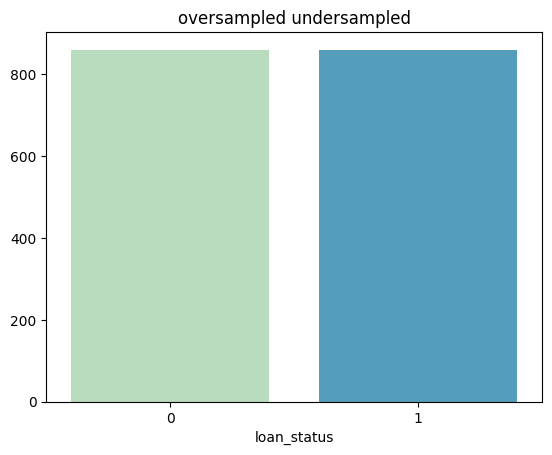

In [92]:
plot_distribution_plot(undersampled_target.value_counts(), "oversampled undersampled")


In [93]:
train=pd.concat([undersampled_data,undersampled_target],axis=1)

### 3.4 Creating dummies


In [94]:
for col in train.select_dtypes(exclude=np.number).columns.tolist():
    df_dum=pd.get_dummies(train[col],prefix=col+"_").astype(int)
    train=train.drop(col,axis=1)
    train=pd.concat([train,df_dum],axis=1)
    
    

In [95]:
for col in test.select_dtypes(exclude=np.number).columns.tolist():
    df_dum=pd.get_dummies(test[col],prefix=col+"_").astype(int)
    test=test.drop(col,axis=1)
    test=pd.concat([test,df_dum],axis=1)
    
    

In [96]:
train.head(3)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status,person_home_ownership__MORTGAGE,person_home_ownership__OTHER,...,loan_intent__PERSONAL,loan_intent__VENTURE,loan_grade__A,loan_grade__B,loan_grade__C,loan_grade__D,loan_grade__E,loan_grade__F,cb_person_default_on_file__N,cb_person_default_on_file__Y
780,22,75000,6.0,10000,6.03,0.13,2,0,1,0,...,0,0,1,0,0,0,0,0,1,0
1325,31,43200,6.0,8000,13.48,0.19,5,0,0,0,...,0,1,0,0,1,0,0,0,0,1
1773,24,42000,8.0,3000,6.76,0.07,3,0,0,0,...,0,0,1,0,0,0,0,0,1,0


In [97]:
test.head(3)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership__MORTGAGE,person_home_ownership__OTHER,person_home_ownership__OWN,...,loan_intent__VENTURE,loan_grade__A,loan_grade__B,loan_grade__C,loan_grade__D,loan_grade__E,loan_grade__F,loan_grade__G,cb_person_default_on_file__N,cb_person_default_on_file__Y
0,23,69000,3.0,25000,15.76,0.36,2,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,26,96000,6.0,10000,12.68,0.10,4,1,0,0,...,0,0,0,1,0,0,0,0,0,1
2,26,30000,5.0,4000,17.19,0.13,2,0,0,0,...,1,0,0,0,0,1,0,0,0,1


In [98]:
for t in test.columns.tolist():
    if t not in train.columns.tolist():
        print(f"the name feature {t} not in test")
    else:
        print(f'{t} is found')

person_age is found
person_income is found
person_emp_length is found
loan_amnt is found
loan_int_rate is found
loan_percent_income is found
cb_person_cred_hist_length is found
person_home_ownership__MORTGAGE is found
person_home_ownership__OTHER is found
person_home_ownership__OWN is found
person_home_ownership__RENT is found
loan_intent__DEBTCONSOLIDATION is found
loan_intent__EDUCATION is found
loan_intent__HOMEIMPROVEMENT is found
loan_intent__MEDICAL is found
loan_intent__PERSONAL is found
loan_intent__VENTURE is found
loan_grade__A is found
loan_grade__B is found
loan_grade__C is found
loan_grade__D is found
loan_grade__E is found
loan_grade__F is found
the name feature loan_grade__G not in test
cb_person_default_on_file__N is found
cb_person_default_on_file__Y is found


In [99]:
test= test.drop(["loan_grade__G"] , axis=1)
train= train.drop(["loan_grade__G"] , axis=1)

In [100]:
X = train.drop('loan_status', axis=1)
y = train['loan_status']

### 3.4 Train test split


In [101]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size = 0.2, random_state = 42)

### 3.5 Feature scaling


In [102]:
from sklearn.preprocessing import StandardScaler

# Creating function for scaling
def Standard_Scaler (df, col_names):
    features = df[col_names]
    scaler = StandardScaler().fit(features.values)
    features = scaler.transform(features.values)
    df[col_names] = features
    
    return df

In [103]:
col_names = num_cols
X_train = Standard_Scaler (X_train, col_names)
X_test = Standard_Scaler (X_test, col_names)
test = Standard_Scaler (test, col_names)

## 4. Model selection

In [104]:
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [105]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score
from sklearn.metrics import classification_report

In [106]:
estimator = []
estimator.append(('Neural Network', MLPClassifier(max_iter = 10000) ))
estimator.append(('LogisticRegression', LogisticRegression(solver ='lbfgs', multi_class ='multinomial', max_iter = 200)))
estimator.append(('ExtraTreesClassifier', ExtraTreesClassifier() ))
estimator.append(('RandomForest', RandomForestClassifier() ))
estimator.append(('SVC', SVC(gamma ='auto', probability = True)))
estimator.append(('AdaBoostClassifier', AdaBoostClassifier() ))
estimator.append(('GradientBoostingClassifier', GradientBoostingClassifier() ))
estimator.append(('XGB', XGBClassifier() ))
estimator.append(('CatBoost', CatBoostClassifier(logging_level='Silent') ))

## 5. Voting Classifier with hard voting


In [107]:
VC_hard = VotingClassifier(estimators = estimator, voting ='hard')
VC_hard.fit(X_train, y_train)
y_pred = VC_hard.predict(X_test)


In [108]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.94      0.95      0.95       172
           1       0.95      0.94      0.94       172

    accuracy                           0.94       344
   macro avg       0.94      0.94      0.94       344
weighted avg       0.94      0.94      0.94       344



In [109]:
y.value_counts()

loan_status
0    860
1    860
Name: count, dtype: int64

In [110]:
cm = confusion_matrix(y_test, y_pred)

VC_hard_Recall = recall_score(y_test, y_pred)
VC_hard_Precision = precision_score(y_test, y_pred)
VC_hard_f1 = f1_score(y_test, y_pred)
VC_hard_accuracy = accuracy_score(y_test, y_pred)

print(cm)

[[164   8]
 [ 11 161]]


<Axes: >

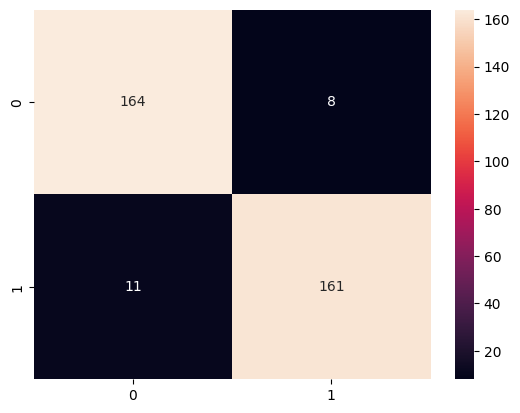

In [111]:
import seaborn as sns
sns.heatmap(cm,fmt="d",annot=True)

In [112]:
from statistics import stdev
score = cross_val_score(VC_hard, X_train, y_train, cv=5, scoring='recall')
VC_hard_cv_score = score.mean()
VC_hard_cv_stdev = stdev(score)
print('Cross Validation Recall scores are: {}'.format(score))
print('Average Cross Validation Recall score: ', VC_hard_cv_score)
print('Cross Validation Recall standard deviation: ', VC_hard_cv_stdev)

Cross Validation Recall scores are: [0.95652174 0.95652174 0.94927536 0.94160584 0.93430657]
Average Cross Validation Recall score:  0.9476462498677668
Cross Validation Recall standard deviation:  0.009677761383810738


In [113]:
ndf = [(VC_hard_Recall, VC_hard_Precision, VC_hard_f1, VC_hard_accuracy, VC_hard_cv_score, VC_hard_cv_stdev)]

VC_hard_score = pd.DataFrame(data = ndf, columns=
                        ['Recall','Precision','F1 Score', 'Accuracy', 'Avg CV Recall', 'Standard Deviation of CV Recall'])
VC_hard_score.insert(0, 'Voting Classifier', 'Hard Voting')
VC_hard_score

,Voting Classifier,Recall,Precision,F1 Score,Accuracy,Avg CV Recall,Standard Deviation of CV Recall
0,Hard Voting,0.936047,0.952663,0.944282,0.944767,0.947646,0.009678


## 6. Voting Classifier with soft voting

In [114]:
VC_soft = VotingClassifier(estimators = estimator, voting ='soft')
VC_soft.fit(X_train, y_train)
y_pred = VC_soft.predict(X_test)
test_pred = VC_soft.predict_proba(test)

In [115]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.94      0.95      0.95       172
           1       0.95      0.94      0.95       172

    accuracy                           0.95       344
   macro avg       0.95      0.95      0.95       344
weighted avg       0.95      0.95      0.95       344



In [116]:
cm = confusion_matrix(y_test, y_pred)

VC_soft_Recall = recall_score(y_test, y_pred)
VC_soft_Precision = precision_score(y_test, y_pred)
VC_soft_f1 = f1_score(y_test, y_pred)
VC_soft_accuracy = accuracy_score(y_test, y_pred)

print(cm)

[[164   8]
 [ 10 162]]


<Axes: >

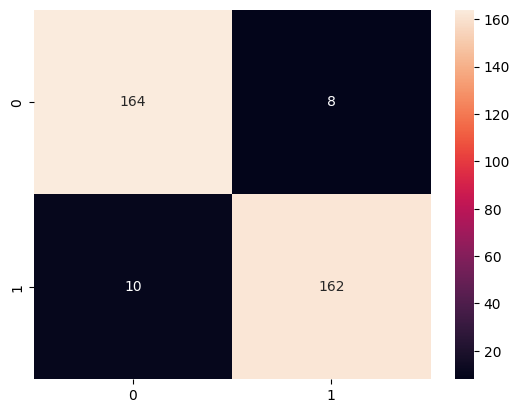

In [117]:
import seaborn as sns
sns.heatmap(cm,fmt="d",annot=True)

In [118]:
score2 = cross_val_score(VC_soft, X_train, y_train, cv=5, scoring='recall')

In [119]:
VC_soft_cv_score = score2.mean()
VC_soft_cv_stdev = stdev(score2)

print('Cross Validation Recall scores are: {}'.format(score2))
print('Average Cross Validation Recall score: ', VC_soft_cv_score)
print('Cross Validation Recall standard deviation: ', VC_soft_cv_stdev)

Cross Validation Recall scores are: [0.95652174 0.97826087 0.96376812 0.96350365 0.94160584]
Average Cross Validation Recall score:  0.9607320427377551
Cross Validation Recall standard deviation:  0.013301293407133643


In [120]:
ndf2 = [(VC_soft_Recall, VC_soft_Precision, VC_soft_f1, VC_soft_accuracy, VC_soft_cv_score, VC_soft_cv_stdev)]

VC_soft_score = pd.DataFrame(data = ndf2, columns=
                        ['Recall','Precision','F1 Score', 'Accuracy', 'Avg CV Recall', 'Standard Deviation of CV Recall'])
VC_soft_score.insert(0, 'Voting Classifier', 'Soft Voting')
VC_soft_score

,Voting Classifier,Recall,Precision,F1 Score,Accuracy,Avg CV Recall,Standard Deviation of CV Recall
0,Soft Voting,0.94186,0.952941,0.947368,0.947674,0.960732,0.013301


## 7. Result comparison


In [121]:
df_VC = pd.concat([VC_soft_score,VC_hard_score],axis=0)
df_VC

,Voting Classifier,Recall,Precision,F1 Score,Accuracy,Avg CV Recall,Standard Deviation of CV Recall
0,Soft Voting,0.941860,0.952941,0.947368,0.947674,0.960732,0.013301
0,Hard Voting,0.936047,0.952663,0.944282,0.944767,0.947646,0.009678


## 8. Make Submission

In [131]:
submission[target_col]=test_pred[:,1]
submission.to_csv('submission.csv',index=False)
submission.head()

ValueError: Length of values (2000) does not match length of index (39098)

## 9.References


I took of the inspiration from the following notebooks

* https://www.kaggle.com/code/marcinrutecki/voting-classifier-for-better-results
* https://www.kaggle.com/code/chickooo/oversampling-undersampling-for-imbalanced-dataset#Combining-oversampling-and-undersampling